In [3]:
import gcsfs
import pandas as pd
import os
from _utils import GCS_FILE_PATH
import geopandas as gpd
import folium
import altair as alt

import matplotlib.pyplot as plt
from pywaffle import Waffle
from pypalettes import load_palette
from pyfonts import load_google_font

In [85]:
df = pd.read_parquet(
    f"{GCS_FILE_PATH}annual_service_and_opex.parquet",
    filesystem = gcsfs.GCSFileSystem()
)

In [5]:
df.head(2)

,key,ntd_id,mode,year,type_of_service,unlinked_passenger_trips,vehicle_revenue_hours,vehicle_revenue_miles,vehicles_operated_in_maxiumum_service,passenger_miles_traveled,...,uza_population,source_agency,source_city,source_state,upt_prior_year,upt_change_1yr,upt_pct_change_1yr,mode_full_name,type_of_service_full_name,service_type
0,8ba07c3a4edfcb413278c890a0b3b541,00007,MB,2024,PT,13865,5784,129301,3,356741,...,270179,Lane Transit District (LTD),Eugene,OR,13050,815,0.0625,Bus,Purchased Transportation,Fixed Route
1,768d38a1c4079ce315353b735ec41298,00007,VP,2020,PT,30475,6810,312462,16,1661859,...,270179,Lane Transit District (LTD),Eugene,OR,40994,-10519,-0.2566,Vanpool,Purchased Transportation,Demand Response


Waffle Chart for time series 

In [6]:
df.columns

Index(['key', 'ntd_id', 'mode', 'year', 'type_of_service',
       'unlinked_passenger_trips', 'vehicle_revenue_hours',
       'vehicle_revenue_miles', 'vehicles_operated_in_maxiumum_service',
       'passenger_miles_traveled', 'direction_route_miles',
       'operating_expenses_vehicle_operations',
       'operating_expenses_vehicle_maintenance',
       'operating_expenses_nonvehicle_maintenance',
       'operating_expenses_general_administration', 'operating_expenses_total',
       'fare_revenue', 'opex_per_vrh', 'opex_per_vrm', 'opex_per_upt',
       'upt_per_vrh', 'upt_per_vrm', 'farebox_recovery_ratio', 'agency_status',
       'census_year', 'last_report_year', 'mode_status', 'reporter_type',
       'reporting_module', 'uace_code', 'uza_area_sq_miles',
       'primary_uza_name', 'uza_population', 'source_agency', 'source_city',
       'source_state', 'upt_prior_year', 'upt_change_1yr',
       'upt_pct_change_1yr', 'mode_full_name', 'type_of_service_full_name',
       'service_type'

In [7]:
df_agg =(df
    .groupby(["year", "mode"])
    ["unlinked_passenger_trips"]
    .sum()
    .reset_index())

In [8]:
all_years = df_agg["year"].unique()
all_modes = df_agg["mode"].unique()

idx = pd.MultiIndex.from_product(
    [all_years, all_modes], names=["year", "mode"]
)

df_agg = (
    df_agg.set_index(["year", "mode"])
    .reindex(idx, fill_value=0)
    .reset_index()
)

df_agg = df_agg.sort_values(["year", "mode"])
df_agg[df_agg["year"] == 2024].sort_values("unlinked_passenger_trips")
df_agg["israilbus"] = df_agg["mode"].isin(["MB", "DR"])
df_agg.head()

,year,mode,unlinked_passenger_trips,israilbus
0,2015,CB,12060734,False
1,2015,CC,6834184,False
2,2015,CR,35821800,False
3,2015,DR,23795831,True
4,2015,FB,5031924,False


In [86]:
df_CA = df[df["primary_uza_name"].str.endswith(", CA", na=False)]

In [10]:
drop_modes = ["CC", "OR", "TB", "TR"]
keep_years = [2019, 2020, 2021, 2022, 2023, 2024]

df_agg = df_agg[
    (~df_agg["mode"].isin(drop_modes)) &
    (df_agg["year"].isin(keep_years))
]


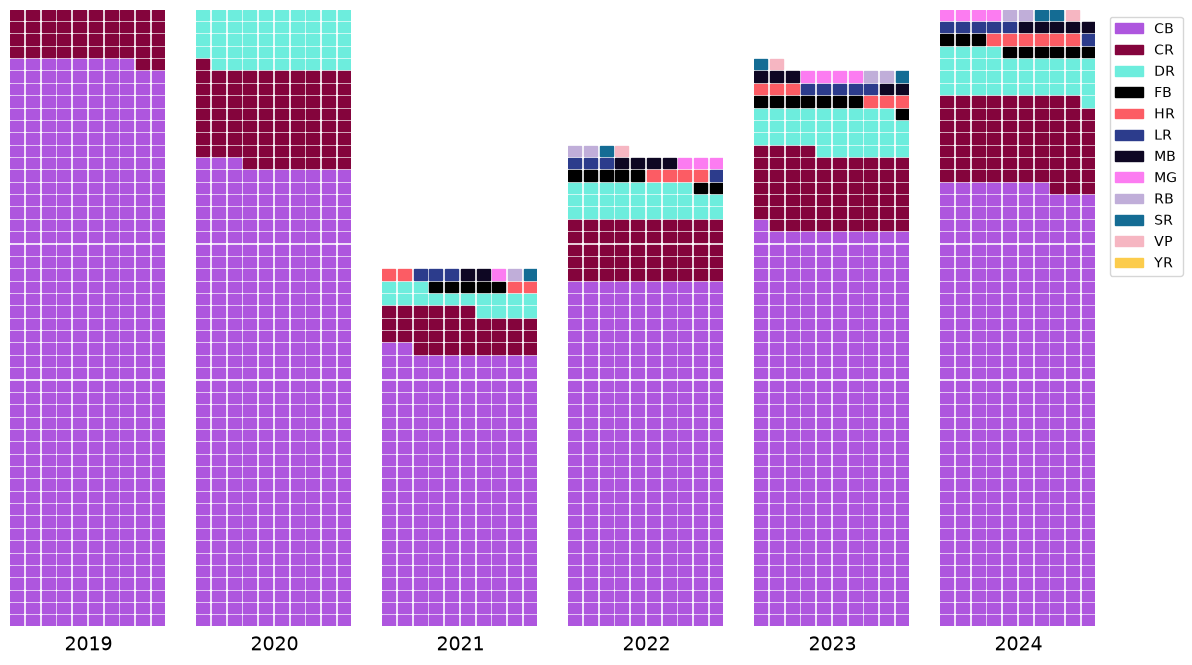

In [11]:
n_colors = df_agg["mode"].nunique()
colors = load_palette("CrystalGems", keep_first_n=n_colors, shuffle=9) + ["white"]
max_year_value = df_agg[df_agg["year"] == 2024]["unlinked_passenger_trips"].sum()
ncols = df_agg["year"].nunique()
fig, axs = plt.subplots(ncols=ncols, figsize=(14, 8))

for year, ax in zip(df_agg["year"].unique(), axs):
    values = list(df_agg[df_agg["year"] == year]["unlinked_passenger_trips"].values)
    values = sorted(values, reverse=True)
    values.append(max_year_value - sum(values))

    Waffle.make_waffle(
        ax=ax,
        rows=50,
        columns=10,
        values=values,
        vertical=True,
        colors=colors,
    )
    
    ax.yaxis.set_visible(True)
    ax.set_yticks(ax.get_yticks())

    ax.text(x=0.1, y=-0.04, s=f"{int(year)}", fontsize=14, ha="center")
    
from matplotlib.patches import Patch

plt.legend(
    handles=[Patch(color=colors[i], label=mode) for i, mode in enumerate(df_agg["mode"].unique())],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.show()

This waffle chart shows the distribution of unlinked passenger trips across different transit modes for each year. Each panel represents a year, and the colored squares indicate each mode’s share of total passenger trips. The chart uses a 50 × 10 grid (500 squares), where each square represents approximately 0.2% of the total trips for that year. Larger sections of the same color represent transit modes with higher passenger volumes, while smaller sections represent modes with lower usage.

In [16]:
selected_uza = [
    'Los Angeles--Long Beach--Anaheim, CA',
    'San Francisco--Oakland, CA',
    'San Diego, CA',
    'San Jose, CA',
    'Sacramento, CA'
]

df_CA_5 = df_CA[
    df_CA['primary_uza_name'].isin(selected_uza)
].copy()

Transit ridership changed from 2021 to 2024 across different modes and across the five California urbanized areas,

In [17]:
alt.Chart(
    df_CA_5,
    title='Post-COVID Vehicle Revenue Hours Change by Mode and Urbanized Area'
).mark_trail().encode(
    alt.X('year:O')
        .title(None),

    alt.Y('mode_full_name:N')
        .title('Mode'),

    alt.Size('vehicle_revenue_hours:Q')
        .scale(range=[5, 20])
        .legend(values=[20, 60])
        .title('Vehicle Revenue Hours'),

    alt.Color('delta:Q')
        .scale(
            domainMid=0,
            range=['maroon', 'lightgray', 'blue']
        )
        .title('UPT Delta (%)'),

    alt.Tooltip([
        'year:O',
        'vehicle_revenue_hours:Q'
    ]),

    alt.Column('primary_uza_name:N')
        .title('UZA')
).transform_pivot(
    pivot='year',
    value='vehicle_revenue_hours',
    groupby=[
        'mode_full_name',
        'primary_uza_name'
    ]
).transform_calculate(
    delta="datum['2024'] - datum['2021']"
).transform_fold(
    ['2021', '2024'],
    as_=['year', 'vehicle_revenue_hours']
).properties(
    width=200,
    height=400
).configure_legend(
    orient='bottom',
    direction='horizontal'
).configure_view(
    stroke=None
)

alt.Chart(...)

The chart compares UPT from 2021 to 2024 across five California urbanized areas. Each panel is an urbanized area, the Y-axis shows transit modes, and the X-axis shows the two years. The trail connects 2021 and 2024 UPT values, with thickness representing the UPT level in each year. Blue indicates an increase, while maroon indicates a decrease. A tapered trail means the UPT level changed between the two years, while a straight trail means the levels were similar.